# AI-Image Detection — the six paradigms, by hand

A hands-on companion to `notebooks/Etsy_final.ipynb`. One section per detection
**paradigm** — each shows *what the signal actually looks like* with plots, not just a
score:

| # | Paradigm | Core idea | Where it lives in your repo |
|---|----------|-----------|------------------------------|
| 1 | **Spatial-domain** | learn real-vs-fake straight from RGB pixels | EfficientNet branch |
| 2 | **Frequency-domain** | spectral artifacts from generator up-sampling | your FFT feature |
| 3 | **Fingerprint-based** | per-generator noise residual pattern | (new angle — cousin of ELA) |
| 4 | **Patch-based** | score local regions, not the whole image | RINE / "where the signal lives" |
| 5 | **Training-free** | reconstruction error, no labelled training | DIRE / AEROBLADE (untried) |
| 6 | **Multimodal reasoning** | a VLM *explains why* it's fake | (new angle — Claude vision) |

**Runs with zero data.** If you don't point it at your Etsy images it falls back to
`skimage` sample photos as *real* and **simulates** generator artifacts for *fake* —
enough to see every signal. Point `REAL_DIR` / `FAKE_DIR` at real folders to use your
actual data.

> ⚠️ The simulated "fakes" reproduce the *mechanism* of a generator artifact (up-sampling
> grid + a faint periodic pattern). They are a teaching device, not real diffusion output.
> Swap in real AI images via the config cell for the real story.

## 0 — Setup & data

Optional deps (`cv2`, `anthropic`) are guarded. Only `numpy / scipy / scikit-learn /
scikit-image / matplotlib / Pillow` are required for sections 1–5.

In [1]:
%matplotlib inline
import io
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import fftpack, ndimage

try:
    import cv2  # noqa: F401  (optional)
except Exception:
    cv2 = None

# ---- CONFIG: set these to your Etsy folders to use real data instead of samples ----
REAL_DIR = None   # e.g. r"C:\\Etsy\\images_final_sample\\real"
FAKE_DIR = None   # e.g. r"C:\\Etsy\\images_final_sample\\ai"
IMG_SIZE = 256
RNG = np.random.default_rng(0)
print("optional cv2:", "available" if cv2 else "absent (fine)")

optional cv2: available


In [2]:
def _load_dir(d, limit=8):
    paths = []
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.webp"):
        paths += list(Path(d).glob(ext))
    imgs = []
    for p in sorted(paths)[:limit]:
        im = Image.open(p).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        imgs.append(np.asarray(im, dtype=np.uint8))
    return imgs

def _sample_reals():
    """Real, bundled photographs from scikit-image (no download)."""
    from skimage import data
    from skimage.transform import resize
    raw = [data.astronaut(), data.coffee(), data.chelsea(), data.rocket()]
    out = []
    for im in raw:
        im = resize(im, (IMG_SIZE, IMG_SIZE), preserve_range=True, anti_aliasing=True)
        out.append(im.astype(np.uint8))
    return out

def simulate_fake(img, factor=3, amp=6.0, period=4.0):
    """Cheap stand-in for a generator: down/up-sample (introduces a blocky up-sampling
    grid) plus a faint periodic pattern (GAN-style spectral fingerprint). Illustrative
    of the *mechanism* only — not real diffusion output."""
    from skimage.transform import resize
    h, w = img.shape[:2]
    small = resize(img, (h // factor, w // factor), preserve_range=True, anti_aliasing=True)
    up = resize(small, (h, w), order=0, preserve_range=True, anti_aliasing=False)  # nearest
    yy, xx = np.mgrid[0:h, 0:w]
    grid = amp * (np.sin(2 * np.pi * xx / period) + np.sin(2 * np.pi * yy / period))
    return np.clip(up + grid[..., None], 0, 255).astype(np.uint8)

def to_gray(img):
    return np.asarray(Image.fromarray(img).convert("L"), dtype=np.float64)

if REAL_DIR and FAKE_DIR:
    reals, fakes, SOURCE = _load_dir(REAL_DIR), _load_dir(FAKE_DIR), "your data"
else:
    reals = _sample_reals()
    fakes = [simulate_fake(im) for im in reals]
    SOURCE = "skimage samples + SIMULATED fakes"
print(f"Loaded {len(reals)} real / {len(fakes)} fake   (source: {SOURCE})")

Loaded 4 real / 4 fake   (source: skimage samples + SIMULATED fakes)


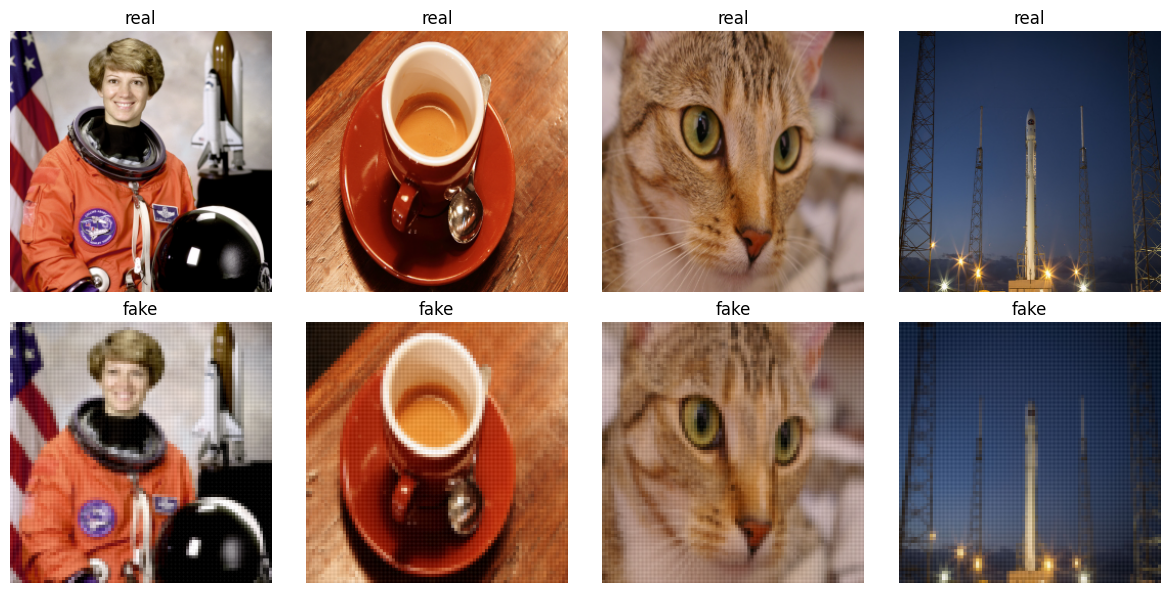

In [3]:
n = len(reals)
fig, ax = plt.subplots(2, n, figsize=(3 * n, 6))
for i, (r, f) in enumerate(zip(reals, fakes)):
    ax[0, i].imshow(r); ax[0, i].set_title("real"); ax[0, i].axis("off")
    ax[1, i].imshow(f); ax[1, i].set_title("fake"); ax[1, i].axis("off")
plt.tight_layout(); plt.show()

## 1 — Spatial-domain: a classifier on raw pixels

The standard supervised detector: feed RGB pixels to a CNN and learn real-vs-fake. Your
**EfficientNet-B0/B3** branch is the production version of this. A deep net discovers its
own features; here, to run on CPU in seconds, we hand it a few **local spatial
statistics** per patch — brightness, local contrast, and gradient/sharpness per channel —
and let a RandomForest separate them. The point: **the pixel domain carries a learnable
signal** (here the fakes are smoother, so their gradients are weaker).

*Caveat: a handful of images is a toy; this shows the paradigm, not a real detector. The
real lift comes from a deep net (your EfficientNet) learning richer features + augmentation.*

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def patch_feats(img, n=300, size=24):
    """Local spatial statistics per patch: mean (brightness), std (contrast),
    and mean |gradient| in x/y (sharpness) for each RGB channel."""
    h, w = img.shape[:2]
    F = []
    for _ in range(n):
        y = RNG.integers(0, h - size); x = RNG.integers(0, w - size)
        p = img[y:y + size, x:x + size].astype(np.float32)
        gx = np.abs(np.diff(p, axis=1)); gy = np.abs(np.diff(p, axis=0))
        row = []
        for c in range(3):
            row += [p[..., c].mean(), p[..., c].std(),
                    gx[..., c].mean(), gy[..., c].mean()]
        F.append(row)
    return np.asarray(F, dtype=np.float32)

X, y = [], []
for im in reals: X.append(patch_feats(im)); y.append(np.zeros(len(X[-1])))
for im in fakes: X.append(patch_feats(im)); y.append(np.ones(len(X[-1])))
X = np.vstack(X); y = np.concatenate(y)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
clf = RandomForestClassifier(n_estimators=200, random_state=0).fit(Xtr, ytr)
print("spatial-statistics RandomForest validation accuracy:",
      round(accuracy_score(yte, clf.predict(Xte)), 3))
feat_names = [f"{s}_{c}" for c in "RGB" for s in ("mean", "std", "gradx", "grady")]
top = np.argsort(clf.feature_importances_)[::-1][:4]
print("most useful spatial features:", [feat_names[i] for i in top])

spatial-statistics RandomForest validation accuracy: 0.925
most useful spatial features: ['grady_R', 'grady_G', 'grady_B', 'gradx_R']


## 2 — Frequency-domain: spectral fingerprints

Generators up-sample with transposed/interp convolutions, which leave **periodic grid
artifacts** invisible in pixels but loud in the Fourier domain (Durall 2020, Frank 2020).
The right panel — the **azimuthally-averaged radial power spectrum** — *is exactly the
FFT feature in your pipeline*. Watch the fake curve lift at high frequencies / show
peaks.

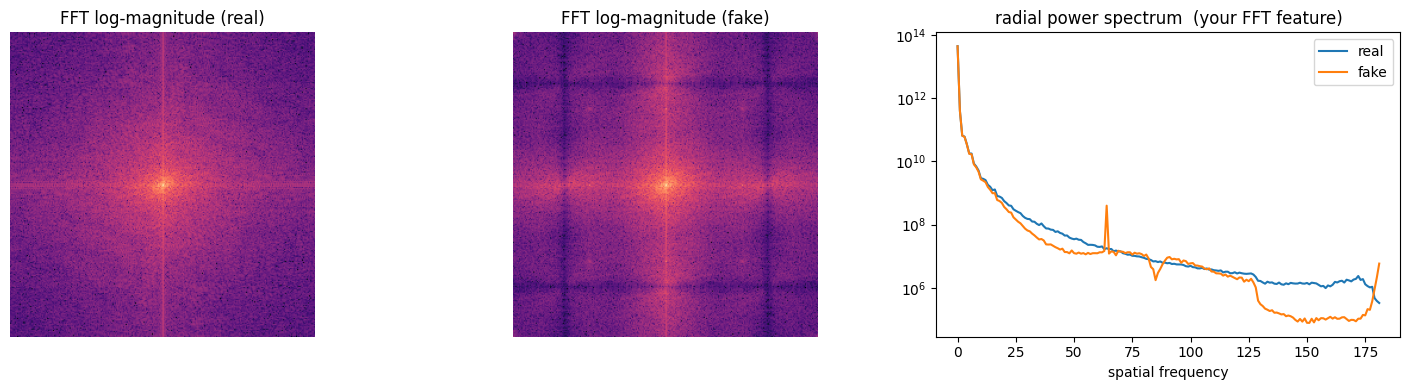

In [7]:
def radial_psd(gray):
    F = np.abs(fftpack.fftshift(fftpack.fft2(gray))) ** 2
    h, w = gray.shape; cy, cx = h // 2, w // 2
    yy, xx = np.mgrid[0:h, 0:w]
    r = np.hypot(yy - cy, xx - cx).astype(int)
    tbin = np.bincount(r.ravel(), F.ravel())
    nr = np.bincount(r.ravel())
    return tbin / np.maximum(nr, 1)

r_gray, f_gray = to_gray(reals[0]), to_gray(fakes[0])
Fr = np.log1p(np.abs(fftpack.fftshift(fftpack.fft2(r_gray))))
Ff = np.log1p(np.abs(fftpack.fftshift(fftpack.fft2(f_gray))))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(Fr, cmap="magma"); ax[0].set_title("FFT log-magnitude (real)"); ax[0].axis("off")
ax[1].imshow(Ff, cmap="magma"); ax[1].set_title("FFT log-magnitude (fake)"); ax[1].axis("off")
pr = np.mean([radial_psd(to_gray(i)) for i in reals], axis=0)
pf = np.mean([radial_psd(to_gray(i)) for i in fakes], axis=0)
ax[2].semilogy(pr, label="real"); ax[2].semilogy(pf, label="fake")
ax[2].set_title("radial power spectrum  (your FFT feature)")
ax[2].set_xlabel("spatial frequency"); ax[2].legend()
plt.tight_layout(); plt.show()

## 3 — Fingerprint-based: per-generator noise residuals

A generator leaves a *stable* noise signature (Marra 2019, Corvi 2023). Isolate it with a
**noise residual** = image − denoised(image), then **average over many images**: real
scene content averages toward grey noise, but the generator's fingerprint survives.
ELA in your repo is a coarse cousin of this. The FFT of the *fake* fingerprint shows
structured peaks; the *real* one does not.

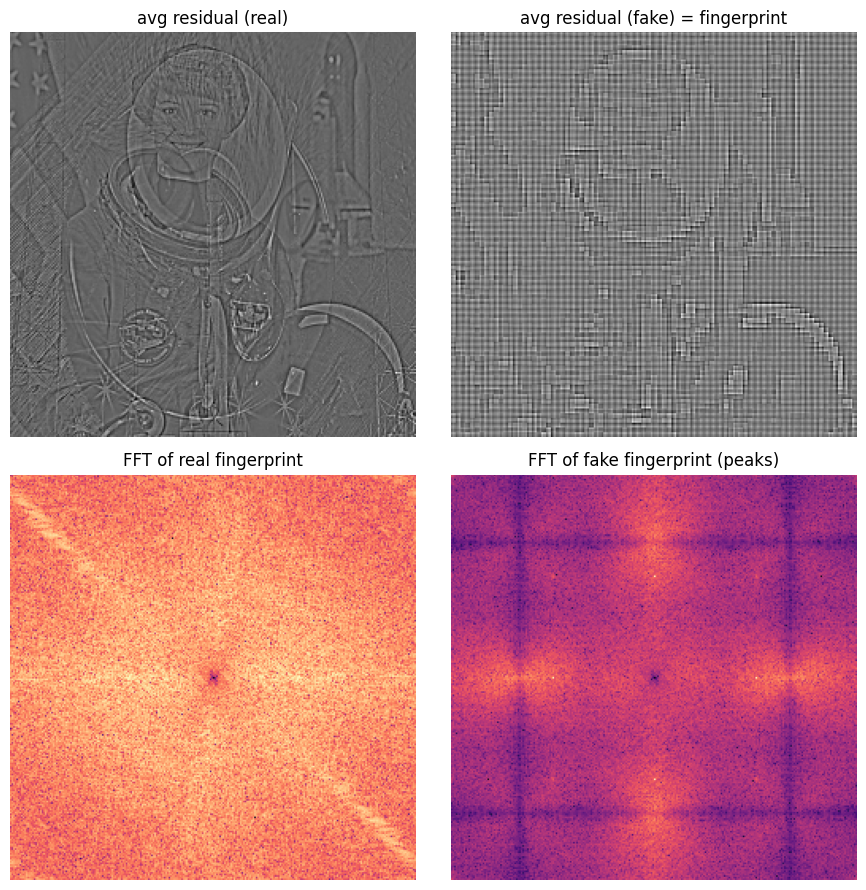

In [8]:
def residual(img, sigma=1.0):
    g = to_gray(img)
    return g - ndimage.gaussian_filter(g, sigma)   # high-pass = noise residual

fp_real = np.mean([residual(i) for i in reals], axis=0)
fp_fake = np.mean([residual(i) for i in fakes], axis=0)

def logfft(a):
    return np.log1p(np.abs(fftpack.fftshift(fftpack.fft2(a))))

fig, ax = plt.subplots(2, 2, figsize=(9, 9))
ax[0, 0].imshow(fp_real, cmap="gray"); ax[0, 0].set_title("avg residual (real)"); ax[0, 0].axis("off")
ax[0, 1].imshow(fp_fake, cmap="gray"); ax[0, 1].set_title("avg residual (fake) = fingerprint"); ax[0, 1].axis("off")
ax[1, 0].imshow(logfft(fp_real), cmap="magma"); ax[1, 0].set_title("FFT of real fingerprint"); ax[1, 0].axis("off")
ax[1, 1].imshow(logfft(fp_fake), cmap="magma"); ax[1, 1].set_title("FFT of fake fingerprint (peaks)"); ax[1, 1].axis("off")
plt.tight_layout(); plt.show()

## 4 — Patch-based: where does the signal live?

Instead of one score per image, score **local regions** and build a heatmap. This is the
RINE intuition — the discriminative signal is *local*, and a partly-edited image (an Etsy
seller AI-retouching half a real photo) only betrays itself in the edited region. We
splice **left half real | right half fake** and score each patch by its high-frequency
energy: the heatmap should light up the fake half.

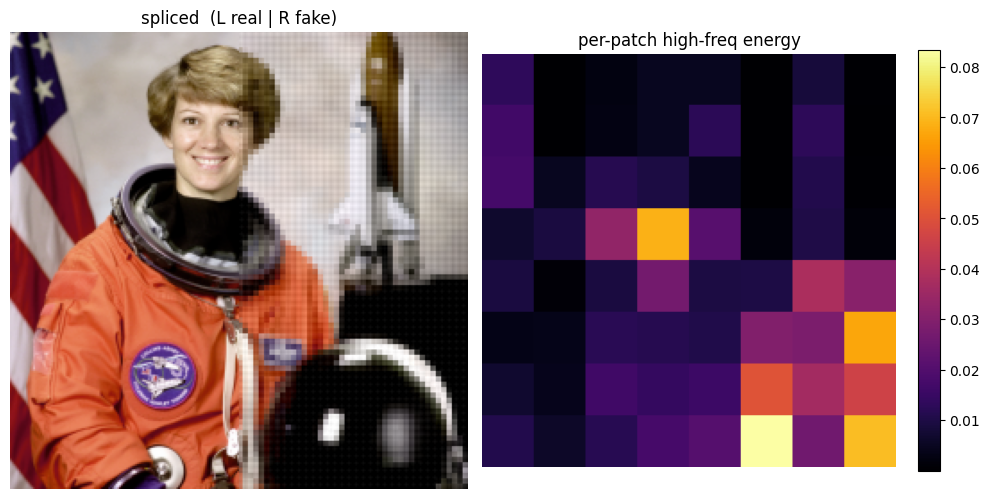

In [9]:
spliced = reals[0].copy()
spliced[:, IMG_SIZE // 2:] = fakes[0][:, IMG_SIZE // 2:]

def hf_energy(gray):
    F = np.abs(fftpack.fftshift(fftpack.fft2(gray))) ** 2
    h, w = gray.shape; cy, cx = h // 2, w // 2
    yy, xx = np.mgrid[0:h, 0:w]
    r = np.hypot(yy - cy, xx - cx)
    hi = r > min(h, w) * 0.25
    return F[hi].sum() / F.sum()

P = 32
g = to_gray(spliced)
heat = np.zeros((IMG_SIZE // P, IMG_SIZE // P))
for i in range(0, IMG_SIZE, P):
    for j in range(0, IMG_SIZE, P):
        heat[i // P, j // P] = hf_energy(g[i:i + P, j:j + P])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(spliced); ax[0].set_title("spliced  (L real | R fake)"); ax[0].axis("off")
im = ax[1].imshow(np.kron(heat, np.ones((P, P))), cmap="inferno")
ax[1].set_title("per-patch high-freq energy"); ax[1].axis("off")
plt.colorbar(im, ax=ax[1], fraction=0.046); plt.tight_layout(); plt.show()

## 5 — Training-free: reconstruction error

No labels, no detector training. **DIRE** and **AEROBLADE** push an image through a
diffusion model's invert-reconstruct loop (or its VAE) and measure the reconstruction
error: generated images reconstruct *differently* than real ones.

Here we use a **PCA "autoencoder" fit on real patches** as a zero-dependency stand-in:
project each patch to 20 components and back, and measure the error. Because the basis is
learned from *real* texture, real patches reconstruct with lower error than the simulated
fakes — the two histograms separate.

> Sign depends on what the autoencoder was trained on: PCA-on-real → *real* reconstructs
> better; AEROBLADE's LDM-VAE → *fake* reconstructs better. Same mechanism, opposite sign.
> See the DIRE sketch below, and the optional real-AEROBLADE cell.

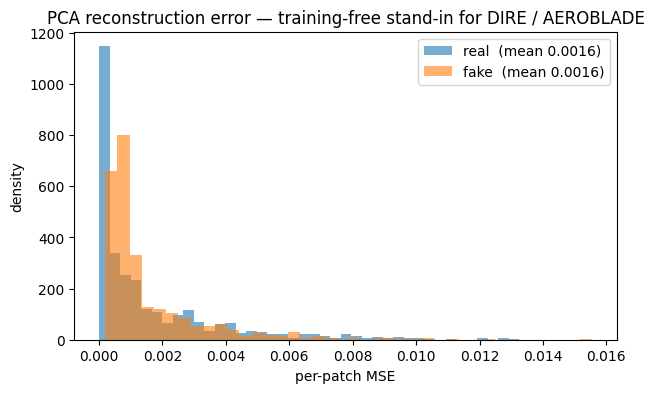

In [10]:
from sklearn.decomposition import PCA

def patch_matrix(imgs, size=16, stride=16):
    M = []
    for im in imgs:
        g = to_gray(im) / 255.0; h, w = g.shape
        for i in range(0, h - size + 1, stride):
            for j in range(0, w - size + 1, stride):
                M.append(g[i:i + size, j:j + size].reshape(-1))
    return np.asarray(M)

real_patches, fake_patches = patch_matrix(reals), patch_matrix(fakes)
pca = PCA(n_components=20).fit(real_patches)          # "autoencoder" trained on REAL only

def recon_err(M):
    return ((M - pca.inverse_transform(pca.transform(M))) ** 2).mean(axis=1)

er, ef = recon_err(real_patches), recon_err(fake_patches)
plt.figure(figsize=(7, 4))
plt.hist(er, bins=40, alpha=.6, density=True, label=f"real  (mean {er.mean():.4f})")
plt.hist(ef, bins=40, alpha=.6, density=True, label=f"fake  (mean {ef.mean():.4f})")
plt.title("PCA reconstruction error — training-free stand-in for DIRE / AEROBLADE")
plt.xlabel("per-patch MSE"); plt.ylabel("density"); plt.legend(); plt.show()

**The real thing — DIRE, in pseudocode** (needs a diffusion model + GPU):

```python
# DIRE = | x - reconstruct(invert(x)) |
latent   = ddim_invert(image, unet)      # run the diffusion ODE backwards
recon    = ddim_sample(latent, unet)     # ...then forwards again
dire_map = np.abs(image - recon)         # large for real, small for generated
score    = dire_map.mean()
```

**AEROBLADE** is cheaper — one pass through Stable Diffusion's VAE, no full inversion:
`err = |x - vae.decode(vae.encode(x))|`. Generated images pass through the VAE almost
losslessly; real ones don't. Uncomment the cell below if you have `diffusers` + a GPU.

In [9]:
# Optional real AEROBLADE-lite (heavy: downloads Stable Diffusion VAE, wants a GPU).
# import torch
# from diffusers import AutoencoderKL
# vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").eval()
# def aeroblade_error(img):
#     x = torch.from_numpy((to_gray.__self__ if False else None))  # build a [1,3,H,W] tensor in [-1,1]
#     with torch.no_grad():
#         rec = vae.decode(vae.encode(x).latent_dist.mean).sample
#     return (x - rec).abs().mean().item()
print("DIRE/AEROBLADE need a diffusion model + GPU — see pseudocode above; PCA cell shows the mechanism.")

DIRE/AEROBLADE need a diffusion model + GPU — see pseudocode above; PCA cell shows the mechanism.


## 6 — Multimodal reasoning: a VLM that explains *why*

Every method above outputs a number. A vision-language model can output a **verdict plus
human-readable evidence** — "the hand has six fingers", "text in the background is
garbled", "lighting on the product is inconsistent". That's a different kind of detector:
interpretable, and strong on *semantic* implausibility that frequency methods miss.

Below is a runnable scaffold against **Claude (`claude-opus-4-8`) vision**, asking for a
**structured JSON** verdict so you can fold it into your ensemble. It no-ops cleanly
without the SDK / key, so the notebook still runs end-to-end.

```
pip install anthropic        # then: set ANTHROPIC_API_KEY in your environment
```

In [10]:
import os, base64, json

def encode_png(img):
    buf = io.BytesIO(); Image.fromarray(img).save(buf, format="PNG")
    return base64.standard_b64encode(buf.getvalue()).decode()

FORENSIC_PROMPT = (
    "You are an image-forensics expert for an online marketplace. Decide whether this "
    "product image is an authentic photograph or AI-generated (diffusion/GAN). Look for "
    "anomalous hands/fingers, garbled text, impossible reflections/shadows, over-smooth "
    "or plastic textures, warped geometry, and watermark residue. Return your verdict, a "
    "confidence in [0,1], and a short list of concrete visual evidence."
)

SCHEMA = {
    "type": "object",
    "properties": {
        "verdict": {"type": "string", "enum": ["authentic", "ai_generated"]},
        "confidence": {"type": "number"},
        "evidence": {"type": "array", "items": {"type": "string"}},
        "reasoning": {"type": "string"},
    },
    "required": ["verdict", "confidence", "evidence", "reasoning"],
    "additionalProperties": False,
}

def vlm_verdict(img, model="claude-opus-4-8"):
    try:
        import anthropic
    except ImportError:
        print("anthropic SDK not installed -> `pip install anthropic`"); return None
    if not os.getenv("ANTHROPIC_API_KEY"):
        print("ANTHROPIC_API_KEY not set -> skipping live call"); return None
    client = anthropic.Anthropic()
    resp = client.messages.create(
        model=model,
        max_tokens=1024,
        messages=[{"role": "user", "content": [
            {"type": "image",
             "source": {"type": "base64", "media_type": "image/png", "data": encode_png(img)}},
            {"type": "text", "text": FORENSIC_PROMPT},
        ]}],
        output_config={"format": {"type": "json_schema", "schema": SCHEMA}},
    )
    text = next(b.text for b in resp.content if b.type == "text")
    return json.loads(text)

# Runs only if the SDK + key are present; otherwise prints why and returns None.
result = vlm_verdict(fakes[0])
print(json.dumps(result, indent=2) if result else "(no live verdict — see message above)")

anthropic SDK not installed -> `pip install anthropic`
(no live verdict — see message above)


## Mapping back to your pipeline

| Paradigm here | Your model | Idea to try next |
|---|---|---|
| 1 Spatial | EfficientNet-B0/B3 | blur+JPEG augmentation (Wang 2020) for generalization |
| 2 Frequency | FFT radial spectrum | add a **DCT** view (Frank 2020) |
| 3 Fingerprint | ELA (cousin) | average residuals → **attribute** which generator |
| 4 Patch | (intermediate-CLIP is global) | per-patch CLIP scoring for partial edits / inpainting |
| 5 Training-free | — (untried) | drop **AEROBLADE/DIRE** in as an ensemble member |
| 6 VLM reasoning | — (untried) | Claude vision verdict as an interpretable ensemble vote + fuse listing text |

These six are not rivals — your 0.941 ensemble already blends **semantic (CLIP)** +
**texture (EfficientNet)** + **frequency (FFT)**. Sections 5 and 6 are the genuinely new
axes worth adding.